# Final Portfolio Assessment 2026 – Vision Task
## Brain Tumor MRI Image Classification

**Name:** Anush Acharya

**Student ID:** 2406798

**Module:** 6CS012 – Artificial Intelligence and Machine Learning


This notebook implements every requirement of **Part II: Vision Tasks** from the Final Portfolio Assessment 2026 brief.




## Part A – Section 2.5.1: Data Understanding, Analysis, Visualization and Cleaning


### Import core libraries
Loads NumPy, Matplotlib, PIL and TensorFlow/Keras for image manipulation and model building.


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suppress C++ INFO/WARNING spam

import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
import tensorflow as tf

# Don't try to hide GPU:0 — set_visible_devices conflicts with TF's locked runtime
# and causes AlreadyExistsError. Just enable memory growth on every DirectML device.
gpus = tf.config.list_physical_devices("GPU")
print(f"DirectML devices: {len(gpus)}")
for i, g in enumerate(gpus):
    print(f"  GPU:{i} -> {g}")

for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except RuntimeError as e:
        print(f"Could not set memory growth on {g.name}: {e}")

if gpus:
    print("Memory growth enabled on all DirectML devices.")
else:
    print("No GPU detected - running on CPU.")


tf.config.run_functions_eagerly(True)
print("Eager execution enabled globally.")


DirectML devices: 2
  GPU:0 -> PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  GPU:1 -> PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
Memory growth enabled on all DirectML devices.
Eager execution enabled globally.


### Define dataset paths
Sets the absolute paths for the training and test image folders.


In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"GPU detected via DirectML: {len(gpus)} device(s)")
    for gpu in gpus:
        print(" ", gpu)
else:
    print("No GPU detected - running on CPU.")

print("Compute policy: float32 (mixed_float16 disabled for DirectML stability)")

GPU detected via DirectML: 2 device(s)
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
Compute policy: float32 (mixed_float16 disabled for DirectML stability)


### List class folders for train and test
Lists the four class folders (`glioma_tumor`, `meningioma_tumor`, `pituitary_tumor`, `normal`) and confirms the directory structure.


In [4]:
base_dataset_path = 'D:\semester6\AI\AI Assesment\Brain Tumor Classifcation'
train_dir = os.path.join(base_dataset_path, "train")
test_dir = os.path.join(base_dataset_path, "test")

In [5]:
import os

print("Checking classes in train directory:")
if os.path.exists(train_dir):
    class_names = os.listdir(train_dir)
    print("Train Classes:", class_names)
else:
    print(f"Train directory not found: {train_dir}")
    class_names = []

print("\nChecking classes in test directory:")
if os.path.exists(test_dir):
    test_class_names = os.listdir(test_dir)
    print("Test Classes:", test_class_names)
else:
    print(f"Test directory not found: {test_dir}")


Checking classes in train directory:
Train Classes: ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']

Checking classes in test directory:
Test Classes: ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']


### Compute class distribution
Counts the number of images per class for both the training and test directories using `defaultdict`.


In [6]:
import os
from collections import defaultdict


train_class_count = defaultdict(int)

for cls in class_names:
    path = os.path.join(train_dir, cls)
    if os.path.exists(path):
        train_class_count[cls] = len(os.listdir(path))
    else:
        print(f"Warning: Training directory for class '{cls}' not found at {path}")

print("Train Class Distribution:", dict(train_class_count))


test_class_count = defaultdict(int)

if 'test_class_names' in locals() and test_class_names:
    for cls in test_class_names:
        path = os.path.join(test_dir, cls)
        if os.path.exists(path):
            test_class_count[cls] = len(os.listdir(path))
        else:
            print(f"Warning: Test directory for class '{cls}' not found at {path}")
    print("Test Class Distribution:", dict(test_class_count))
else:
    print("Test classes not found or test_class_names is empty. Cannot determine test class distribution.")

Train Class Distribution: {'glioma_tumor': 713, 'meningioma_tumor': 723, 'normal': 343, 'pituitary_tumor': 668}
Test Class Distribution: {'glioma_tumor': 181, 'meningioma_tumor': 183, 'normal': 88, 'pituitary_tumor': 169}


### Total image count
Reports the total number of training and test images.


In [7]:
total_train_images = sum(train_class_count.values())
total_test_images = sum(test_class_count.values())

print(f"\nTotal Training Images: {total_train_images}")
print(f"Total Test Images: {total_test_images}")


Total Training Images: 2447
Total Test Images: 621


### Visualize training class distribution
Plots a bar chart showing how images are distributed across the four classes in the training set.


C:\Users\NITRO\AppData\Local\Temp\ipykernel_26156\3756527101.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_counts_series.index, y=train_counts_series.values, palette='viridis')


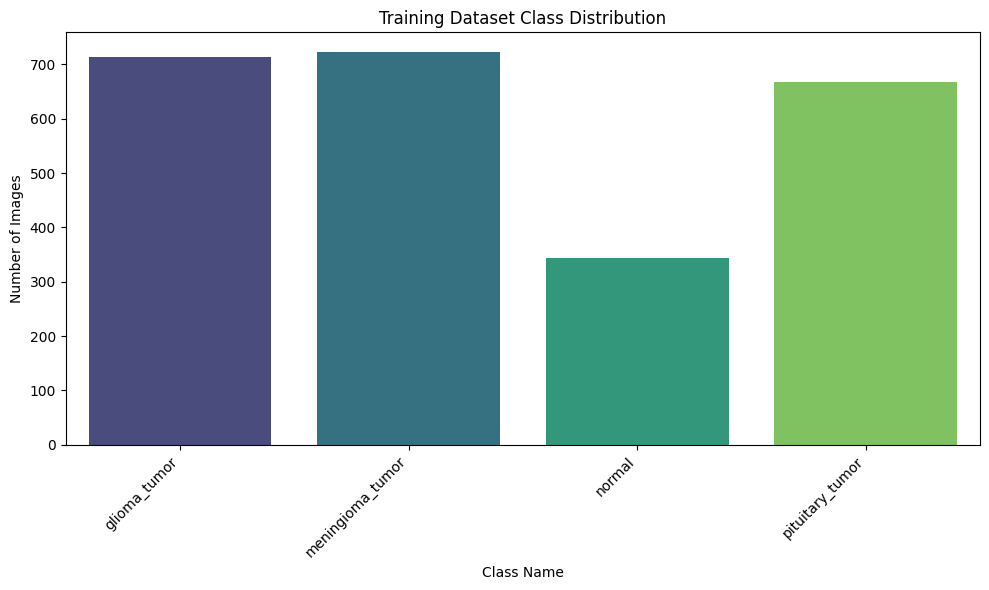

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


train_counts_series = pd.Series(train_class_count)

plt.figure(figsize=(10, 6))
sns.barplot(x=train_counts_series.index, y=train_counts_series.values, palette='viridis')
plt.title('Training Dataset Class Distribution')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Visualize test class distribution
Plots a bar chart for the test set distribution. This shows whether the dataset is balanced.


C:\Users\NITRO\AppData\Local\Temp\ipykernel_26156\145142733.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_counts_series.index, y=test_counts_series.values, palette='viridis')


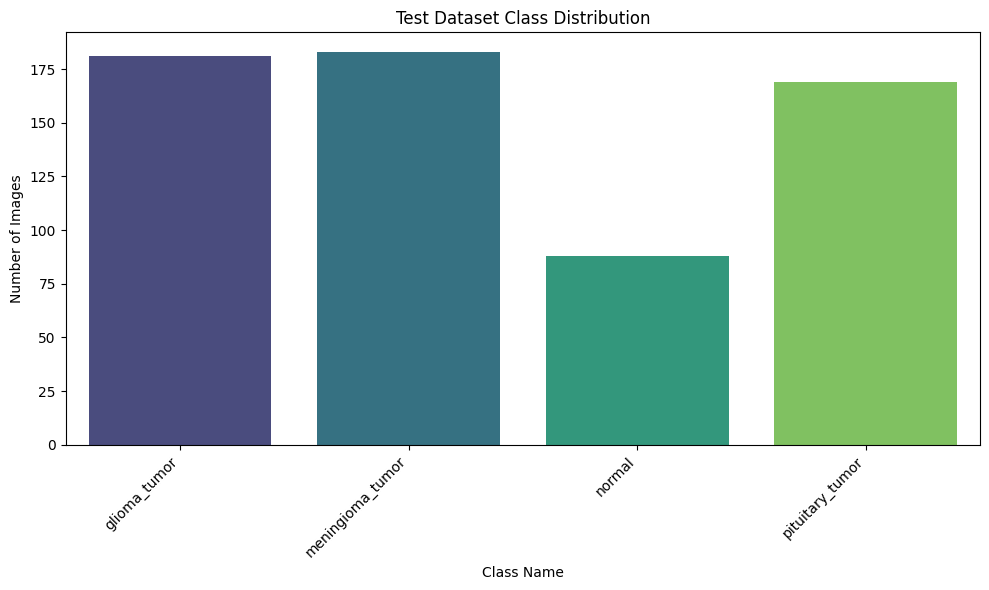

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


test_counts_series = pd.Series(test_class_count)

plt.figure(figsize=(10, 6))
sns.barplot(x=test_counts_series.index, y=test_counts_series.values, palette='viridis')
plt.title('Test Dataset Class Distribution')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Display random sample images
Shows one random image from each class so we can visually inspect the data quality and resolution.


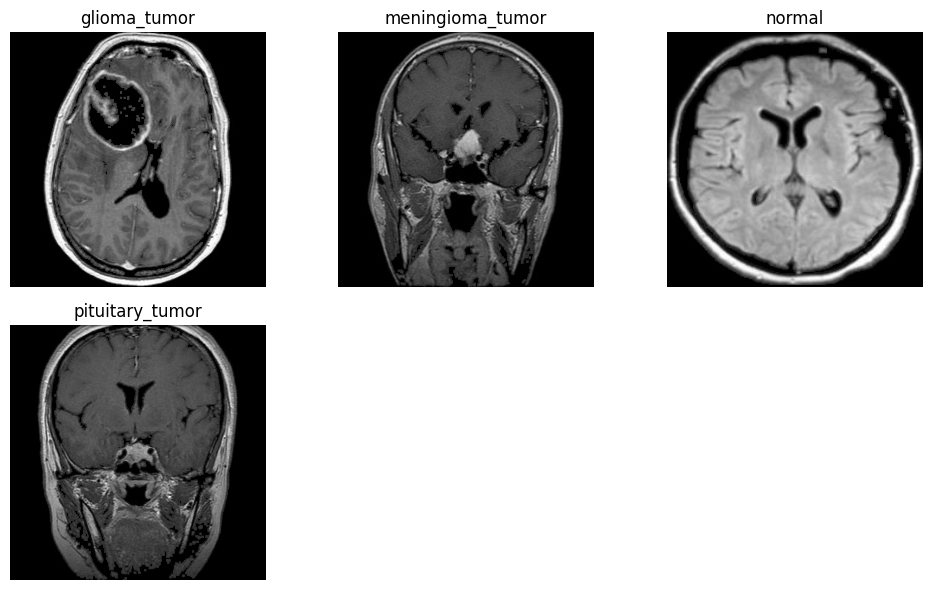

In [10]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(10,6))


loaded_images_count = 0

for i, cls in enumerate(class_names):

    if loaded_images_count >= 6:
        break

    path = os.path.join(train_dir, cls)
    if not os.path.exists(path):
        print(f"Warning: Class directory not found: {path}")
        continue

    img_files = os.listdir(path)
    if not img_files:
        print(f"Warning: No images found in directory: {path}")
        continue

    try:
        img_name = random.choice(img_files)
        img_path = os.path.join(path, img_name)
        img = plt.imread(img_path)

        plt.subplot(2,3,loaded_images_count + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
        loaded_images_count += 1

    except Exception as e:
        print(f"Could not load image {img_path}: {e}")
        continue

plt.tight_layout()
plt.show()

### Check for corrupted images
Iterates through all training images and uses `PIL.Image.verify()` to detect any corrupted or unreadable files.


In [11]:
from PIL import Image

corrupted = []

for cls in class_names:
    path = os.path.join(train_dir, cls)

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 0


### Remove corrupted images
Removes any corrupted images that were identified, then re-runs the corruption check to confirm the dataset is clean.


In [12]:
import os

print(f"Removing {len(corrupted)} corrupted images...")
for img_path in corrupted:
    if os.path.exists(img_path):
        os.remove(img_path)
        # print(f"Removed: {img_path}") # Uncomment to see individual removals

print("Corrupted images removed. Re-checking corrupted images...")

# Re-run the corrupted image check to confirm
corrupted_after_removal = []

for cls in class_names:
    path = os.path.join(train_dir, cls)

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted_after_removal.append(img_path)

print("Corrupted Images after removal:", len(corrupted_after_removal))

Removing 0 corrupted images...
Corrupted images removed. Re-checking corrupted images...
Corrupted Images after removal: 0


### Recalculate class distribution after cleaning
Recounts images per class after the cleanup step.


In [13]:
import os
from collections import defaultdict


print("Re-calculating Train Class Distribution after removal...")
train_class_count = defaultdict(int)

for cls in class_names:
    path = os.path.join(train_dir, cls)
    if os.path.exists(path):
        train_class_count[cls] = len(os.listdir(path))
    else:
        print(f"Warning: Training directory for class '{cls}' not found at {path}")

print("Train Class Distribution:", dict(train_class_count))


print("Re-calculating Test Class Distribution after removal...")
test_class_count = defaultdict(int)

if 'test_class_names' in locals() and test_class_names:
    for cls in test_class_names:
        path = os.path.join(test_dir, cls)
        if os.path.exists(path):
            test_class_count[cls] = len(os.listdir(path))
        else:
            print(f"Warning: Test directory for class '{cls}' not found at {path}")
    print("Test Class Distribution:", dict(test_class_count))
else:
    print("Test classes not found or test_class_names is empty. Cannot determine test class distribution.")

Re-calculating Train Class Distribution after removal...
Train Class Distribution: {'glioma_tumor': 713, 'meningioma_tumor': 723, 'normal': 343, 'pituitary_tumor': 668}
Re-calculating Test Class Distribution after removal...
Test Class Distribution: {'glioma_tumor': 181, 'meningioma_tumor': 183, 'normal': 88, 'pituitary_tumor': 169}


### Total image count after cleaning
Reports the post-cleaning totals.


In [14]:
total_train_images = sum(train_class_count.values())
total_test_images = sum(test_class_count.values())

print(f"\nTotal Training Images: {total_train_images}")
print(f"Total Test Images: {total_test_images}")


Total Training Images: 2447
Total Test Images: 621


### Re-plot train distribution after cleaning


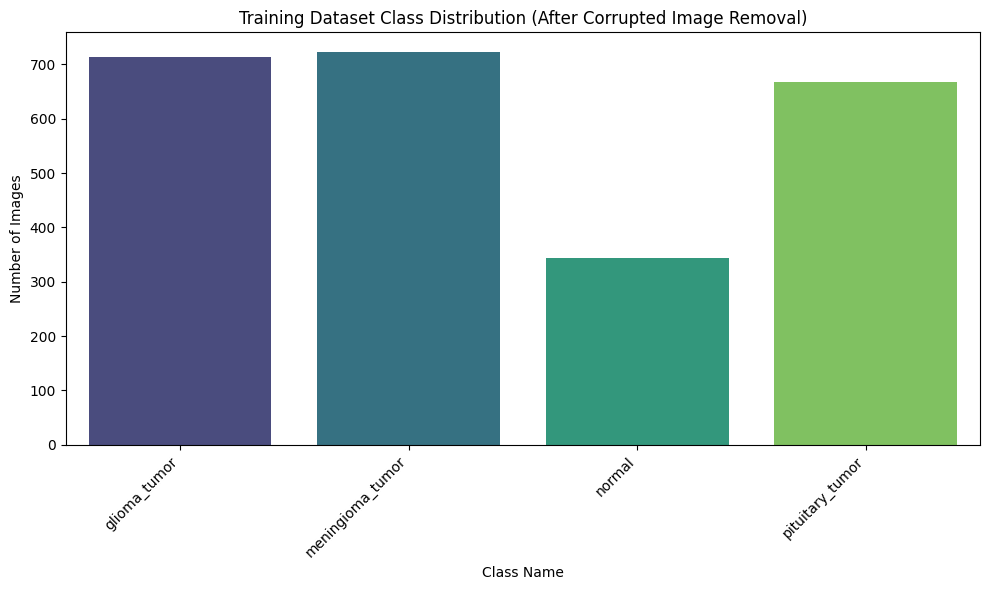

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


train_counts_series = pd.Series(train_class_count)

plt.figure(figsize=(10, 6))
sns.barplot(x=train_counts_series.index, y=train_counts_series.values, hue=train_counts_series.index, palette='viridis', legend=False)
plt.title('Training Dataset Class Distribution (After Corrupted Image Removal)')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Re-plot test distribution after cleaning


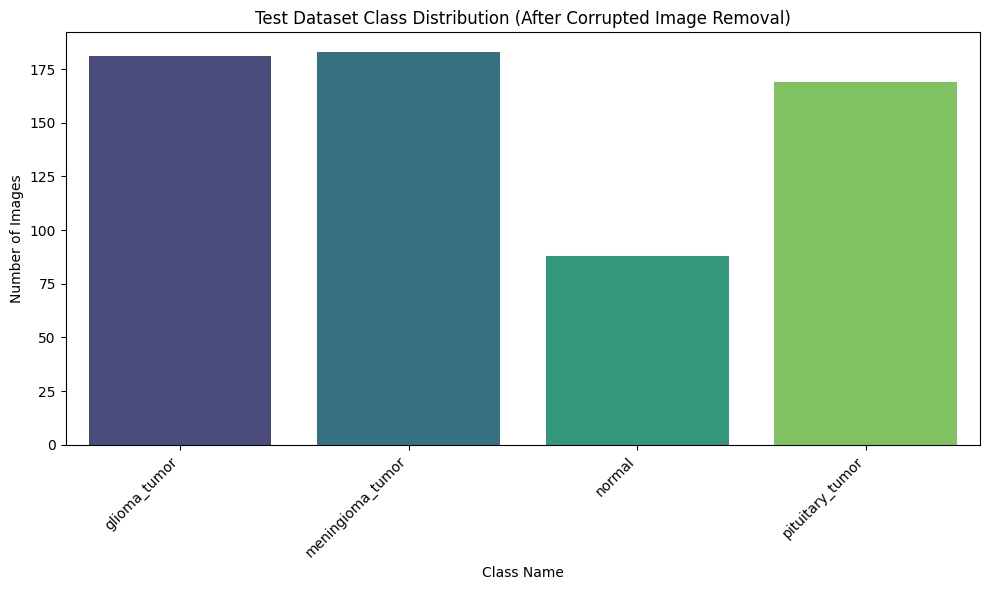

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


test_counts_series = pd.Series(test_class_count)

plt.figure(figsize=(10, 6))
sns.barplot(x=test_counts_series.index, y=test_counts_series.values, hue=test_counts_series.index, palette='viridis', legend=False)
plt.title('Test Dataset Class Distribution (After Corrupted Image Removal)')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Part A – Image Loading and Augmentation Setup


### Define image size and batch size
All images will be resized to 224×224 pixels (matching the input size required by VGG16 for Part B). Batch size is set to 8.


In [17]:
import tensorflow as tf
from tensorflow.keras import layers

image_size = (224, 224)
batch_size = 8

### Load train/validation datasets with 80/20 split
Uses `image_dataset_from_directory` to load the training data and split it 80/20 into training and validation. `batch_size=None` so we can apply per-image augmentation before batching.


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=None
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=None 
)

Found 2447 files belonging to 4 classes.
Using 1958 files for training.


d:\semester6\AI\AI Assesment\venv\lib\site-packages\tensorflow\python\data\ops\structured_function.py:264: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Found 2447 files belonging to 4 classes.
Using 489 files for validation.


### Confirm class names and locate the 'normal' class index
Captures the list of class names from the dataset and finds the index for the `normal` class so augmentation can be applied selectively.


In [19]:
class_names = train_ds.class_names
print("Classes:", class_names)

# Get index of 'normal'
normal_class_index = class_names.index("normal")
print("Normal class index:", normal_class_index)

Classes: ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']
Normal class index: 2


### Define the data augmentation pipeline
Defines random horizontal flip, ±10% rotation and ±20% zoom for use as augmentation.


In [20]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

### Apply augmentation only to the 'normal' class
The `normal` class is under-represented (343 images vs ~700 for tumor classes). To rebalance, augmentation is applied only to images of the `normal` class.


In [ ]:
def augment_only_normal(images, labels):
    with tf.device('/CPU:0'):
        images = tf.cast(images, tf.float32)

        is_normal = tf.equal(labels, normal_class_index)

        augmented_images_tensor = data_augmentation(tf.expand_dims(images, 0), training=True)[0]
        augmented_images_tensor = tf.cast(augmented_images_tensor, tf.float32)

        images = tf.where(is_normal, augmented_images_tensor, images)
    return images, labels


train_ds = train_ds.map(augment_only_normal, num_parallel_calls=1)


### Visualize sample augmented images
**Brief requirement:** *If data augmentation was applied, provide visualizations of sample augmented images.* This cell displays 6 augmented samples to confirm the pipeline works.


Found 2447 files belonging to 4 classes.


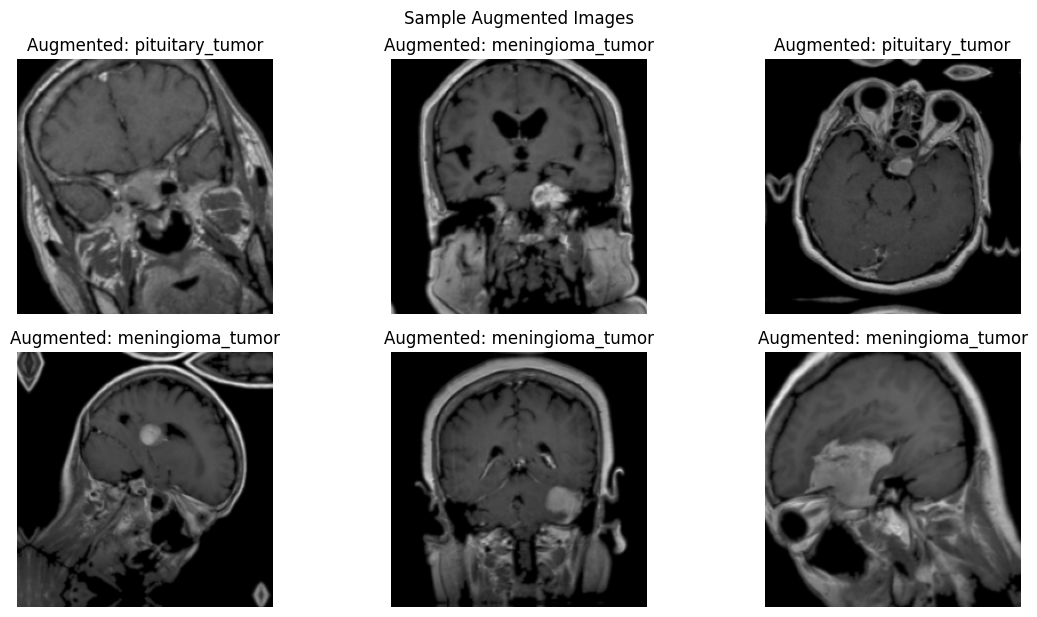

In [22]:
import matplotlib.pyplot as plt

# Take a small unbatched copy to visualize augmentation
sample_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=image_size, batch_size=None, shuffle=True, seed=42
)

plt.figure(figsize=(12, 6))
for i, (img, label) in enumerate(sample_ds.take(6)):
    # DirectML crashes (AlreadyExistsError) when RandomRotation/RandomZoom run on the GPU
    # outside the tf.data pipeline. Force this preview call onto the CPU.
    with tf.device('/CPU:0'):
        img_float = tf.cast(img, tf.float32)
        augmented = data_augmentation(tf.expand_dims(img_float, 0), training=True)[0]

    # Values are already in [0, 255] (data_augmentation does not rescale). Just clip + cast.
    augmented_uint8 = tf.clip_by_value(augmented, 0, 255).numpy().astype('uint8')

    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_uint8)
    plt.title(f"Augmented: {class_names[label.numpy()]}")
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Sample Augmented Images", y=1.02)
plt.show()


### Batch and prefetch
Applies batching (size 32) and `prefetch(AUTOTUNE)` for I/O efficiency.


In [23]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.batch(batch_size).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.batch(batch_size).prefetch(buffer_size=AUTOTUNE)

## Part A – Section 2.5.2: Baseline CNN Model

**Brief requirement:** Build a baseline CNN with **3 Convolutional layers + pooling, 3 Fully Connected layers, output layer**, specifying kernel sizes, filter counts, and activations.


### Build baseline CNN model (3 conv + 3 FC)
Constructs the simple baseline architecture as required by the brief: 3 conv blocks with 3×3 kernels and ReLU activation, followed by 3 dense layers.


In [24]:
import gc
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Rescaling, Input, Dropout,
    BatchNormalization, Activation
)

try:
    del baseline_model
except NameError:
    pass
gc.collect()

img_height, img_width = image_size
num_classes = len(class_names)

print("Building the BASELINE CNN model (3 Conv + 3 FC)...")
baseline_model = Sequential([
    Input(shape=(img_height, img_width, 3)),
    Rescaling(1./255),

    # Conv Block 1
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(fused=False),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Conv Block 2
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(fused=False),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Conv Block 3
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(fused=False),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),

    Dense(256, activation=None),
    BatchNormalization(fused=False),
    Activation('relu'),
    Dropout(0.5),

    Dense(128, activation=None),
    BatchNormalization(fused=False),
    Activation('relu'),
    Dropout(0.5),

    Dense(64, activation=None),
    BatchNormalization(fused=False),
    Activation('relu'),

    Dense(num_classes, activation='softmax')
], name='baseline_cnn')

baseline_model.summary()


Building the BASELINE CNN model (3 Conv + 3 FC)...
Model: "baseline_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 224, 224, 32)      0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 dr

### Compile baseline model
Uses Adam optimizer, sparse categorical cross-entropy loss, and accuracy metric.


In [25]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    run_eagerly=True
)
print("Baseline model compiled.")

Baseline model compiled.


### Train baseline model and time it
**Brief requirement:** train for an appropriate number of epochs and report training time.


In [26]:
import time
from tensorflow.keras.callbacks import EarlyStopping

early_stop_baseline = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

start_time_baseline = time.time()
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop_baseline]
)
baseline_training_time = time.time() - start_time_baseline
print(f"\nBaseline training completed in {baseline_training_time:.2f} seconds.")


Epoch 1/25
245/245 [==============================] - 50s 198ms/step - loss: 1.2011 - accuracy: 0.4566 - val_loss: 2.2481 - val_accuracy: 0.3006
Epoch 2/25
245/245 [==============================] - 38s 152ms/step - loss: 0.9292 - accuracy: 0.6078 - val_loss: 1.7496 - val_accuracy: 0.3456
Epoch 3/25
245/245 [==============================] - 25s 102ms/step - loss: 0.7777 - accuracy: 0.6869 - val_loss: 1.5649 - val_accuracy: 0.5358
Epoch 4/25
245/245 [==============================] - 25s 103ms/step - loss: 0.7326 - accuracy: 0.6977 - val_loss: 0.9924 - val_accuracy: 0.6442
Epoch 5/25
245/245 [==============================] - 25s 101ms/step - loss: 0.6756 - accuracy: 0.7344 - val_loss: 2.9617 - val_accuracy: 0.4949
Epoch 6/25
245/245 [==============================] - 51s 207ms/step - loss: 0.5922 - accuracy: 0.7661 - val_loss: 0.8757 - val_accuracy: 0.6258
Epoch 7/25
245/245 [==============================] - 44s 179ms/step - loss: 0.5423 - accuracy: 0.7880 - val_loss: 1.5574 - val_ac

### Plot baseline training vs validation curves
Plots accuracy and loss for the baseline.


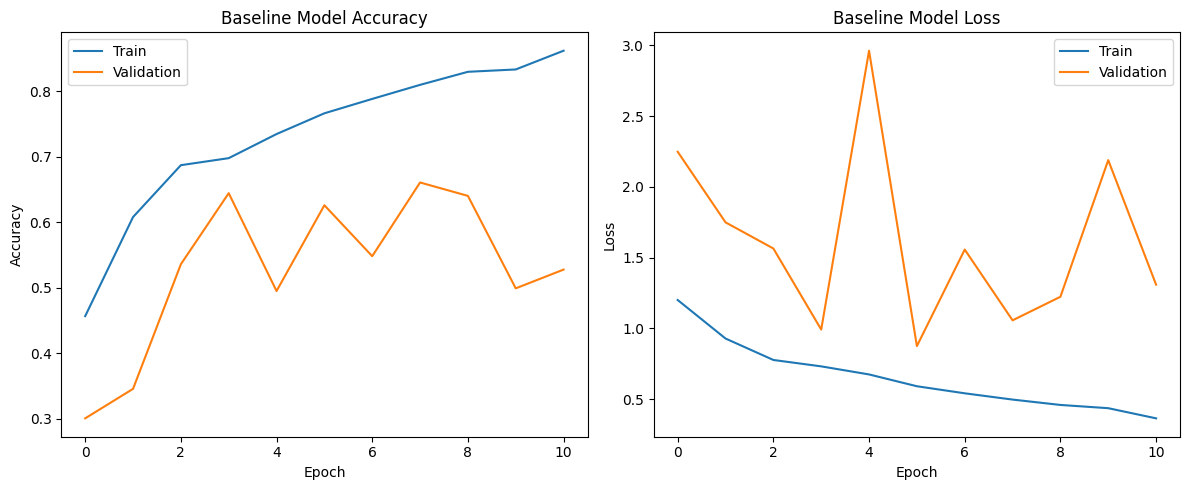

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['accuracy'], label='Train')
plt.plot(history_baseline.history['val_accuracy'], label='Validation')
plt.title('Baseline Model Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['loss'], label='Train')
plt.plot(history_baseline.history['val_loss'], label='Validation')
plt.title('Baseline Model Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()


### Evaluate baseline – Accuracy / Precision / Recall / F1
**Brief requirement:** *Evaluate the model using appropriate metrics (accuracy, precision, recall and F-1 score)*.


In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

baseline_loss, baseline_acc = baseline_model.evaluate(val_ds, verbose=0)
print(f"Baseline Validation Loss: {baseline_loss:.4f}")
print(f"Baseline Validation Accuracy: {baseline_acc:.4f}")

# Per-class metrics
y_true_b, y_pred_b = [], []
for images, labels in val_ds:
    preds = baseline_model.predict(images, verbose=0)
    y_pred_b.extend(np.argmax(preds, axis=1))
    y_true_b.extend(labels.numpy())

print("\nClassification Report (Baseline):")
print(classification_report(y_true_b, y_pred_b, target_names=class_names))
print("Confusion Matrix:")
print(confusion_matrix(y_true_b, y_pred_b))


Baseline Validation Loss: 0.8757
Baseline Validation Accuracy: 0.6258

Classification Report (Baseline):
                  precision    recall  f1-score   support

    glioma_tumor       0.96      0.37      0.53       147
meningioma_tumor       0.47      0.83      0.60       143
          normal       0.66      0.67      0.67        73
 pituitary_tumor       0.81      0.67      0.73       126

        accuracy                           0.63       489
       macro avg       0.73      0.63      0.63       489
    weighted avg       0.73      0.63      0.62       489

Confusion Matrix:
[[ 54  78   8   7]
 [  1 119  11  12]
 [  0  23  49   1]
 [  1  35   6  84]]


### Inference on sample images – baseline
**Brief requirement:** *Perform inference on sample images and plot the result*.


d:\semester6\AI\AI Assesment\venv\lib\site-packages\tensorflow\python\data\ops\structured_function.py:264: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


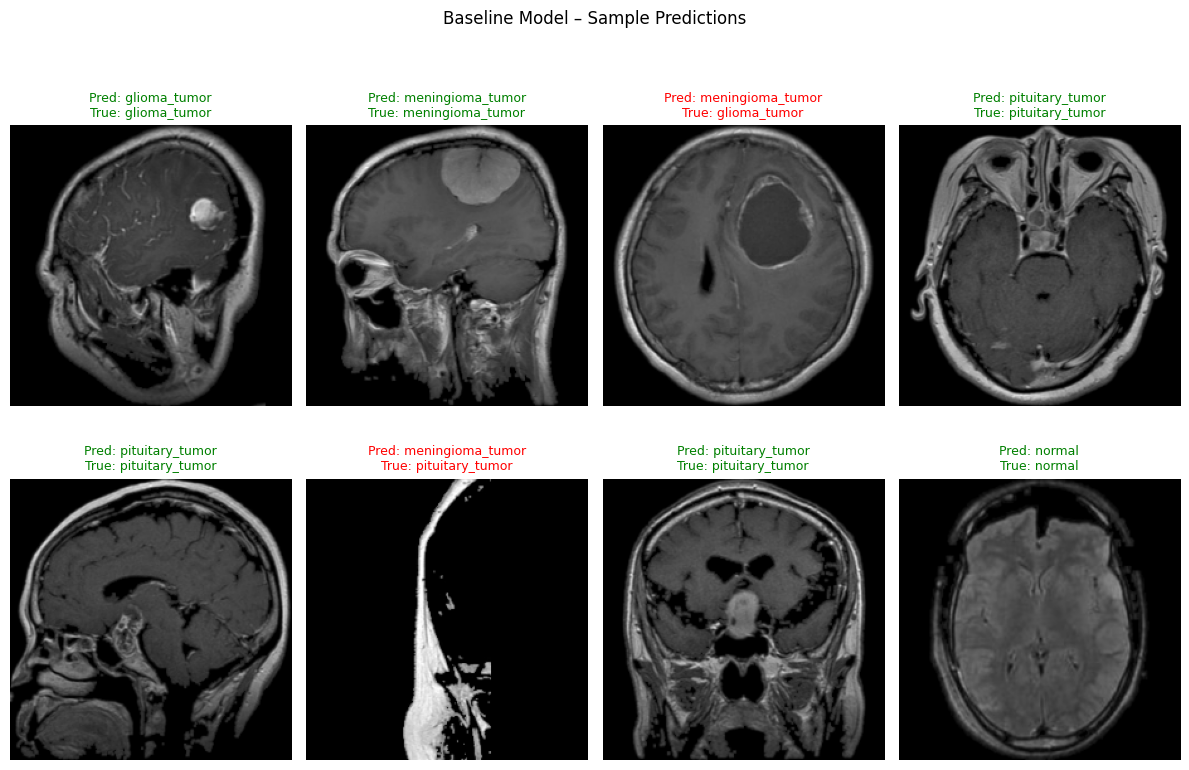

In [29]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))
sample_iter = iter(val_ds.unbatch().take(8))
for i in range(8):
    img, label = next(sample_iter)
    pred = baseline_model.predict(tf.expand_dims(img, 0), verbose=0)
    pred_class = class_names[np.argmax(pred)]
    true_class = class_names[label.numpy()]
    plt.subplot(2, 4, i + 1)
    plt.imshow(img.numpy().astype('uint8'))
    color = 'green' if pred_class == true_class else 'red'
    plt.title(f"Pred: {pred_class}\nTrue: {true_class}", color=color, fontsize=9)
    plt.axis('off')
plt.suptitle("Baseline Model – Sample Predictions", y=1.02)
plt.tight_layout()
plt.show()


## Part A – Section 2.5.3: Deeper CNN with Regularization

**Brief requirement:** Extend the baseline by **at least doubling the layers** and adding regularization (BatchNormalization + Dropout). The deeper model below has 4 conv blocks and 4 FC layers with BN and Dropout — more than double the baseline's depth.


### Build deeper CNN with BatchNorm + Dropout
The deeper architecture from the original notebook: 4 conv blocks with BatchNorm/Dropout, 4 dense layers with BatchNorm/Dropout, and a softmax output.


In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.layers import BatchNormalization, Dropout, Activation


img_height = image_size[0]
img_width = image_size[1]
num_classes = len(class_names)

print("Building the CNN model...")
model = Sequential([
    keras.Input(shape=(img_height, img_width, 3)),

    layers.Rescaling(1./255),

    # First Convolutional Block
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(fused=False),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Second Convolutional Block
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(fused=False),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Third Convolutional Block
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(fused=False),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Fourth Convolutional Block
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(fused=False),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),

    # First Fully Connected Layer
    Dense(512, activation=None),
    BatchNormalization(fused=False),
    Activation('relu'),
    Dropout(0.5),

    # Second Fully Connected Layer
    Dense(256, activation=None),
    BatchNormalization(fused=False),
    Activation('relu'),
    Dropout(0.5),

    # Third Fully Connected Layer
    Dense(128, activation=None),
    BatchNormalization(fused=False),
    Activation('relu'),
    Dropout(0.5),

    # Fourth Fully Connected Layer
    Dense(64, activation=None),
    BatchNormalization(fused=False),
    Activation('relu'),
    Dropout(0.5),

    # Output layer
    Dense(num_classes, activation='softmax')
])

model.summary()


Building the CNN model...
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 224, 224, 32)      896       
                                                                 
 batch_normalization_6 (Batc  (None, 224, 224, 32)     128       
 hNormalization)                                                 
                                                                 
 activation_6 (Activation)   (None, 224, 224, 32)      0         
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 112, 112, 32)     0         
 2D)                                                             
                                                                 
 dropout_5 (Dropout)        

### Cell: Compile deeper model


In [31]:
print("Compiling the model...")
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    run_eagerly=True
)
print("Model compiled successfully.")

Compiling the model...
Model compiled successfully.


### Train deeper model with ModelCheckpoint and EarlyStopping
The deeper model is trained for up to 250 epochs with best-checkpoint and early-stopping callbacks.


In [32]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import time

print("Starting DEEPER model training...")

# Use the new native .keras format - legacy .h5 (HDF5) causes DirectML kernel crashes in TF 2.10.
checkpoint = ModelCheckpoint("best_model.weights.h5", monitor='val_accuracy', save_best_only=True, save_weights_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)

start_time_deeper = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)
deeper_training_time = time.time() - start_time_deeper

print(f"\nDeeper model training completed in {deeper_training_time:.2f} seconds.")


Starting DEEPER model training...
Epoch 1/250
245/245 [==============================] - ETA: 0s - loss: 1.5229 - accuracy: 0.3672
Epoch 1: val_accuracy improved from -inf to 0.35583, saving model to best_model.weights.h5
245/245 [==============================] - 32s 131ms/step - loss: 1.5229 - accuracy: 0.3672 - val_loss: 1.4546 - val_accuracy: 0.3558
Epoch 2/250
245/245 [==============================] - ETA: 0s - loss: 1.3392 - accuracy: 0.4132
Epoch 2: val_accuracy improved from 0.35583 to 0.40900, saving model to best_model.weights.h5
245/245 [==============================] - 31s 124ms/step - loss: 1.3392 - accuracy: 0.4132 - val_loss: 1.9689 - val_accuracy: 0.4090
Epoch 3/250
245/245 [==============================] - ETA: 0s - loss: 1.1717 - accuracy: 0.5020
Epoch 3: val_accuracy improved from 0.40900 to 0.59100, saving model to best_model.weights.h5
245/245 [==============================] - 31s 124ms/step - loss: 1.1717 - accuracy: 0.5020 - val_loss: 1.0245 - val_accuracy: 0

### Save the final deeper model


In [33]:
# model.save('final_model.h5')

### Plot deeper model accuracy and loss curves


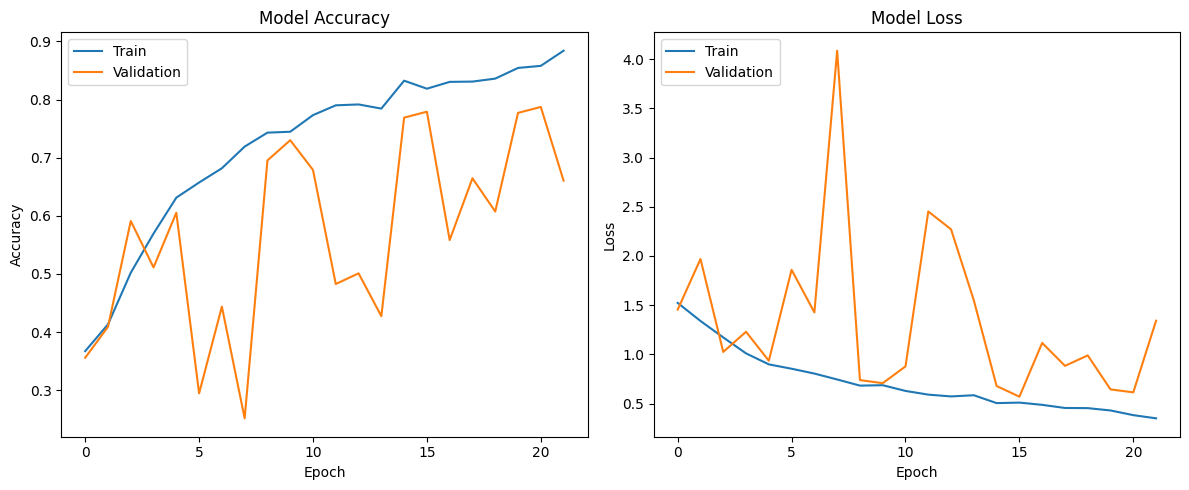

In [34]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


### Evaluate deeper model on the validation set


In [35]:
loss, acc = model.evaluate(val_ds)
print("CNN Accuracy:", acc)

62/62 [==============================] - 1s 17ms/step - loss: 0.5696 - accuracy: 0.7791
CNN Accuracy: 0.7791410684585571


### Print formatted validation loss and accuracy for deeper model


In [36]:
print("Evaluating the model on the validation dataset...")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

Evaluating the model on the validation dataset...
62/62 [==============================] - 1s 17ms/step - loss: 0.5696 - accuracy: 0.7791
Validation Loss: 0.5696
Validation Accuracy: 0.7791


### Classification report and confusion matrix – deeper model
**Brief requirement:** evaluate the deeper model on the same metrics as the baseline (accuracy / precision / recall / F1).


In [37]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true_d, y_pred_d = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred_d.extend(np.argmax(preds, axis=1))
    y_true_d.extend(labels.numpy())

print("Classification Report (Deeper Model):")
print(classification_report(y_true_d, y_pred_d, target_names=class_names))
print("Confusion Matrix:")
print(confusion_matrix(y_true_d, y_pred_d))


Classification Report (Deeper Model):
                  precision    recall  f1-score   support

    glioma_tumor       0.95      0.76      0.84       147
meningioma_tumor       0.68      0.79      0.73       143
          normal       0.58      0.74      0.65        73
 pituitary_tumor       0.92      0.82      0.87       126

        accuracy                           0.78       489
       macro avg       0.78      0.78      0.77       489
    weighted avg       0.81      0.78      0.79       489

Confusion Matrix:
[[111  25  11   0]
 [  2 113  19   9]
 [  2  17  54   0]
 [  2  12   9 103]]


### Inference on sample images – deeper model
Visualizes 8 predictions from the deeper model with green titles for correct predictions and red for incorrect.


d:\semester6\AI\AI Assesment\venv\lib\site-packages\tensorflow\python\data\ops\structured_function.py:264: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


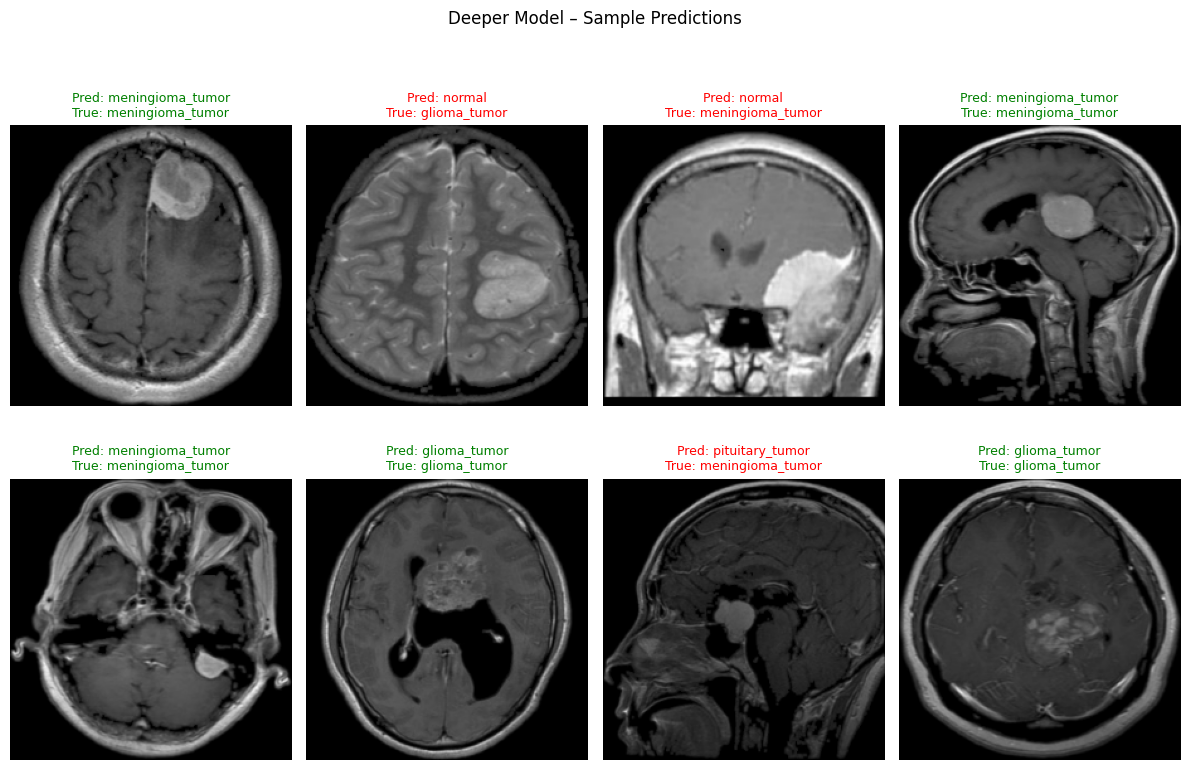

In [38]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))
sample_iter = iter(val_ds.unbatch().take(8))
for i in range(8):
    img, label = next(sample_iter)
    pred = model.predict(tf.expand_dims(img, 0), verbose=0)
    pred_class = class_names[np.argmax(pred)]
    true_class = class_names[label.numpy()]
    plt.subplot(2, 4, i + 1)
    plt.imshow(img.numpy().astype('uint8'))
    color = 'green' if pred_class == true_class else 'red'
    plt.title(f"Pred: {pred_class}\nTrue: {true_class}", color=color, fontsize=9)
    plt.axis('off')
plt.suptitle("Deeper Model – Sample Predictions", y=1.02)
plt.tight_layout()
plt.show()


## Part A – Section 2.5.4: Experimentation and Comparative Analysis

This section addresses every sub-task of the Experimentation block:
1. Baseline vs Deeper Performance
2. Computational Efficiency
3. Optimizer Analysis: SGD vs Adam
4. Ablation Study
5. Challenges and Observations


### Baseline vs Deeper – metric comparison
Compares accuracy, loss and per-class F1-scores side by side.


In [39]:
from sklearn.metrics import f1_score
import pandas as pd

f1_baseline = f1_score(y_true_b, y_pred_b, average='weighted')
f1_deeper = f1_score(y_true_d, y_pred_d, average='weighted')

comparison_df = pd.DataFrame({
    'Model': ['Baseline (3 conv + 3 FC)', 'Deeper (4 conv + 4 FC + BN + Dropout)'],
    'Validation Accuracy': [baseline_acc, accuracy],
    'Validation Loss': [baseline_loss, loss],
    'Weighted F1-Score': [f1_baseline, f1_deeper],
    'Training Time (s)': [baseline_training_time, deeper_training_time]
})
print("Baseline vs Deeper Model Comparison:")
print(comparison_df.to_string(index=False))


Baseline vs Deeper Model Comparison:
                                Model  Validation Accuracy  Validation Loss  Weighted F1-Score  Training Time (s)
             Baseline (3 conv + 3 FC)             0.625767         0.875678           0.622538         365.754538
Deeper (4 conv + 4 FC + BN + Dropout)             0.779141         0.569604           0.786131         720.203950


### Computational efficiency – training time and parameter count
Reports trainable parameters and training time. Hardware acceleration (GPU/TPU on Colab) is also confirmed.


In [40]:
import tensorflow as tf

print("Hardware available:", tf.config.list_physical_devices())
print(f"\nBaseline trainable params: {baseline_model.count_params():,}")
print(f"Deeper   trainable params: {model.count_params():,}")
print(f"\nBaseline training time: {baseline_training_time:.2f}s")
print(f"Deeper   training time: {deeper_training_time:.2f}s")
print(f"\nTrade-off: deeper model has {model.count_params() / baseline_model.count_params():.2f}x more parameters and took {deeper_training_time / baseline_training_time:.2f}x longer to train.")


Hardware available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

Baseline trainable params: 25,827,716
Deeper   trainable params: 26,257,540

Baseline training time: 365.75s
Deeper   training time: 720.20s

Trade-off: deeper model has 1.02x more parameters and took 1.97x longer to train.


### Optimizer Analysis – train deeper architecture with SGD
**Brief requirement:** *Train the deeper model with SGD and then Adam. Compare the impact on convergence speed and final performance.* (The deeper model above already used Adam — here we rebuild and train it with SGD.)


In [41]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import clone_model
import time

# Clone the deeper architecture so we get fresh weights
model_sgd = clone_model(model)
model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    run_eagerly=True
)

early_stop_sgd = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)

start_sgd = time.time()
history_sgd = model_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop_sgd]
)
sgd_time = time.time() - start_sgd
sgd_loss, sgd_acc = model_sgd.evaluate(val_ds, verbose=0)
print(f"\nSGD-trained deeper model: val_acc={sgd_acc:.4f}, val_loss={sgd_loss:.4f}, time={sgd_time:.2f}s")


Epoch 1/20
245/245 [==============================] - 24s 97ms/step - loss: 1.4264 - accuracy: 0.3621 - val_loss: 1.4023 - val_accuracy: 0.3538
Epoch 2/20
245/245 [==============================] - 24s 95ms/step - loss: 1.2530 - accuracy: 0.4178 - val_loss: 1.5577 - val_accuracy: 0.3006
Epoch 3/20
245/245 [==============================] - 24s 95ms/step - loss: 1.1285 - accuracy: 0.4928 - val_loss: 1.1094 - val_accuracy: 0.5890
Epoch 4/20
245/245 [==============================] - 41s 165ms/step - loss: 1.0203 - accuracy: 0.5644 - val_loss: 1.6664 - val_accuracy: 0.4356
Epoch 5/20
245/245 [==============================] - 48s 195ms/step - loss: 0.9468 - accuracy: 0.6098 - val_loss: 1.1048 - val_accuracy: 0.6135
Epoch 6/20
245/245 [==============================] - 47s 191ms/step - loss: 0.8896 - accuracy: 0.6180 - val_loss: 4.5197 - val_accuracy: 0.2638
Epoch 7/20
245/245 [==============================] - 32s 128ms/step - loss: 0.8530 - accuracy: 0.6507 - val_loss: 2.8310 - val_accur

### Optimizer comparison summary – SGD vs Adam
Plots the training curves of both optimizers on the same axes and prints a comparison table.


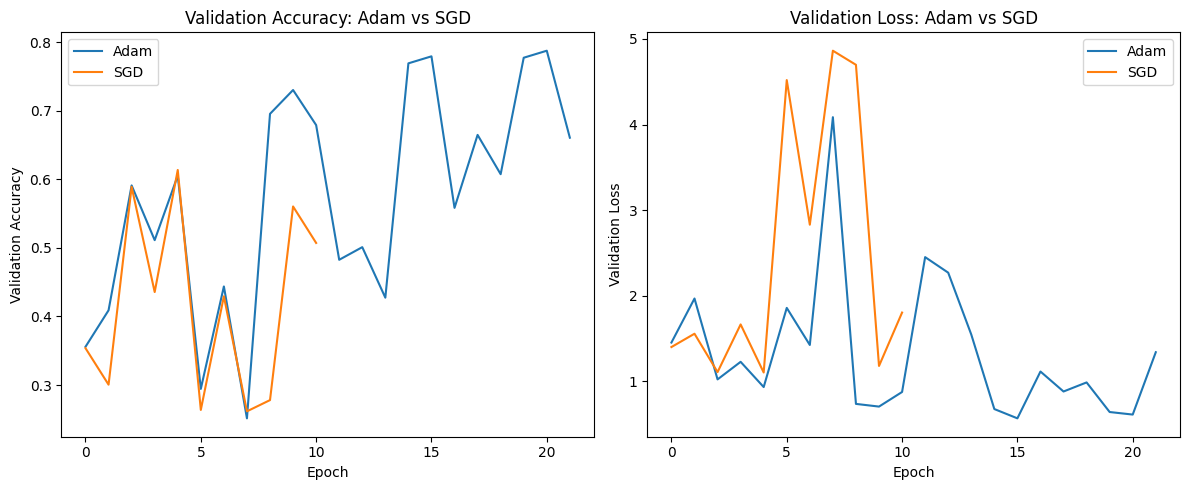

                  Optimizer  Final Val Accuracy  Final Val Loss  Training Time (s)
                       Adam            0.779141        0.569604         720.203950
SGD (lr=0.01, momentum=0.9)            0.613497        1.104830         336.387956


In [42]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['val_accuracy'], label='Adam')
plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.title('Validation Accuracy: Adam vs SGD')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='Adam')
plt.plot(history_sgd.history['val_loss'], label='SGD')
plt.title('Validation Loss: Adam vs SGD')
plt.xlabel('Epoch'); plt.ylabel('Validation Loss'); plt.legend()

plt.tight_layout()
plt.show()

opt_df = pd.DataFrame({
    'Optimizer': ['Adam', 'SGD (lr=0.01, momentum=0.9)'],
    'Final Val Accuracy': [accuracy, sgd_acc],
    'Final Val Loss': [loss, sgd_loss],
    'Training Time (s)': [deeper_training_time, sgd_time]
})
print(opt_df.to_string(index=False))


### Ablation Study – remove Dropout
**Brief requirement:** *Remove one component (e.g., dropout or batch normalization) and analyze how performance changes.* Here Dropout is removed.


In [43]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling, BatchNormalization, Activation
import time

print("Building DEEPER model WITHOUT Dropout (ablation)...")
model_no_dropout = Sequential([
    Input(shape=(img_height, img_width, 3)),
    Rescaling(1./255),

    Conv2D(32, (3, 3), padding='same'), BatchNormalization(fused=False), Activation('relu'), MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), padding='same'), BatchNormalization(fused=False), Activation('relu'), MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), padding='same'), BatchNormalization(fused=False), Activation('relu'), MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), padding='same'), BatchNormalization(fused=False), Activation('relu'), MaxPooling2D((2, 2)),

    Flatten(),
    Dense(512), BatchNormalization(fused=False), Activation('relu'),
    Dense(256), BatchNormalization(fused=False), Activation('relu'),
    Dense(128), BatchNormalization(fused=False), Activation('relu'),
    Dense(64),  BatchNormalization(fused=False), Activation('relu'),

    Dense(num_classes, activation='softmax')
], name='deeper_no_dropout')

model_no_dropout.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'], run_eagerly=True)
early_stop_abl = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)

start_abl = time.time()
history_abl = model_no_dropout.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=[early_stop_abl])
abl_time = time.time() - start_abl
abl_loss, abl_acc = model_no_dropout.evaluate(val_ds, verbose=0)
print(f"\nAblation (no Dropout) val_acc={abl_acc:.4f}, val_loss={abl_loss:.4f}")


Building DEEPER model WITHOUT Dropout (ablation)...
Epoch 1/20
245/245 [==============================] - 28s 113ms/step - loss: 0.9966 - accuracy: 0.5858 - val_loss: 3.4164 - val_accuracy: 0.1554
Epoch 2/20
245/245 [==============================] - 28s 114ms/step - loss: 0.7022 - accuracy: 0.7217 - val_loss: 2.6607 - val_accuracy: 0.3027
Epoch 3/20
245/245 [==============================] - 28s 114ms/step - loss: 0.6149 - accuracy: 0.7666 - val_loss: 0.6978 - val_accuracy: 0.7382
Epoch 4/20
245/245 [==============================] - 28s 115ms/step - loss: 0.5100 - accuracy: 0.8044 - val_loss: 1.2019 - val_accuracy: 0.6789
Epoch 5/20
245/245 [==============================] - 28s 113ms/step - loss: 0.4498 - accuracy: 0.8391 - val_loss: 1.0105 - val_accuracy: 0.6524
Epoch 6/20
245/245 [==============================] - 28s 115ms/step - loss: 0.3992 - accuracy: 0.8539 - val_loss: 2.1486 - val_accuracy: 0.5235
Epoch 7/20
245/245 [==============================] - 28s 114ms/step - loss: 0

### Ablation comparison
Plots ablation vs full deeper model and quantifies the gap.


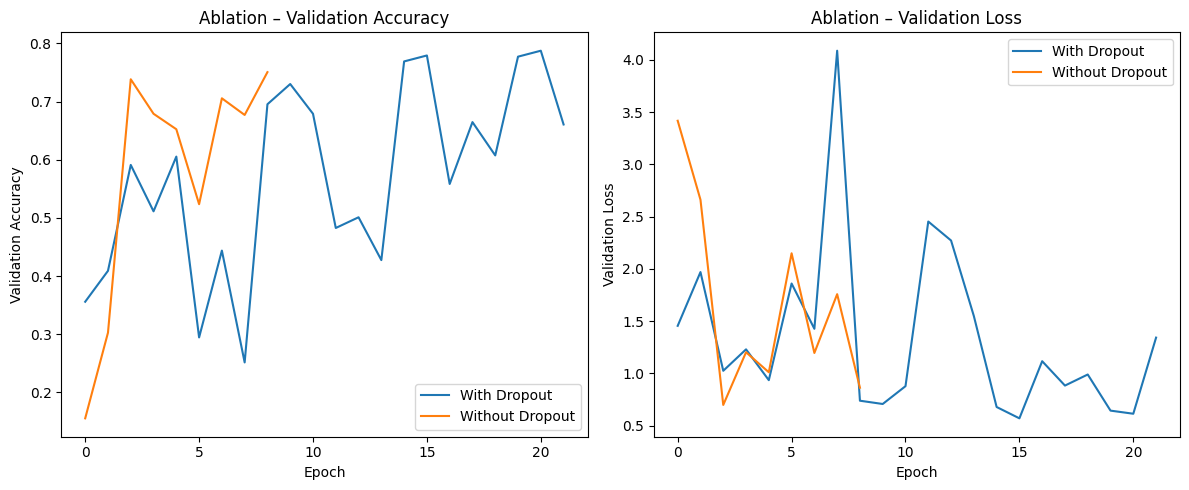

          Configuration  Validation Accuracy  Validation Loss
  Deeper + BN + Dropout             0.779141         0.569604
Deeper + BN, NO Dropout             0.738241         0.697762


In [44]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['val_accuracy'], label='With Dropout')
plt.plot(history_abl.history['val_accuracy'], label='Without Dropout')
plt.title('Ablation – Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='With Dropout')
plt.plot(history_abl.history['val_loss'], label='Without Dropout')
plt.title('Ablation – Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Validation Loss'); plt.legend()

plt.tight_layout()
plt.show()

abl_df = pd.DataFrame({
    'Configuration': ['Deeper + BN + Dropout', 'Deeper + BN, NO Dropout'],
    'Validation Accuracy': [accuracy, abl_acc],
    'Validation Loss': [loss, abl_loss]
})
print(abl_df.to_string(index=False))


## Part B – Section 2.6: Transfer Learning with VGG16

**Brief requirement:** Load a pre-trained CNN (VGG/ResNet/Inception), remove the original FC layers, add new dense layers for the project's class count, then train with feature extraction and (optionally) fine-tuning.


### Load pre-trained VGG16 (ImageNet weights, no top) and freeze its layers
Freezing means the convolutional base keeps its learned ImageNet features and only the new head is trained — the *feature extraction* strategy.


In [45]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

### Add custom classification head for 4 brain-tumor classes
Replaces VGG16's 1000-class ImageNet head with a global-average-pooling → Dense(256) → Dropout → Dense(4 softmax) head matching our classes.


In [46]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(len(class_names), activation='softmax')(x)

vgg_model = tf.keras.Model(inputs=base_model.input, outputs=output)


### Compile and train VGG16 (feature extraction phase)
Trains the new head only, with the conv base frozen, for 10 epochs.


In [47]:
vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    run_eagerly=True
)

history_vgg = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
245/245 [==============================] - 73s 298ms/step - loss: 1.3753 - accuracy: 0.6404 - val_loss: 0.8820 - val_accuracy: 0.6830
Epoch 2/10
245/245 [==============================] - 73s 297ms/step - loss: 0.5867 - accuracy: 0.7676 - val_loss: 0.6444 - val_accuracy: 0.7444
Epoch 3/10
245/245 [==============================] - 73s 297ms/step - loss: 0.5013 - accuracy: 0.8054 - val_loss: 0.6849 - val_accuracy: 0.7526
Epoch 4/10
245/245 [==============================] - 73s 298ms/step - loss: 0.4313 - accuracy: 0.8192 - val_loss: 0.6486 - val_accuracy: 0.7587
Epoch 5/10
245/245 [==============================] - 73s 298ms/step - loss: 0.4264 - accuracy: 0.8294 - val_loss: 0.7666 - val_accuracy: 0.7587
Epoch 6/10
245/245 [==============================] - 73s 298ms/step - loss: 0.3643 - accuracy: 0.8641 - val_loss: 0.7874 - val_accuracy: 0.7239
Epoch 7/10
245/245 [==============================] - 74s 299ms/step - loss: 0.3730 - accuracy: 0.8519 - val_loss: 0.5523 - val_ac

### Evaluate the feature-extraction VGG16


In [48]:
loss_vgg, acc_vgg = vgg_model.evaluate(val_ds)
print("VGG16 Accuracy:", acc_vgg)

62/62 [==============================] - 6s 99ms/step - loss: 0.6472 - accuracy: 0.7975
VGG16 Accuracy: 0.7975459694862366


### Classification report for VGG16 (feature extraction)


In [49]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = vgg_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred))

1/1 [==============================] - 0s 20ms/step


d:\semester6\AI\AI Assesment\venv\lib\site-packages\tensorflow\python\data\ops\structured_function.py:264: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


1/1 [==============================] - 0s 20ms/step
              precision    recall  f1-score   support

           0       0.88      0.82      0.85       147
           1       0.72      0.76      0.74       143
           2       0.94      0.62      0.74        73
           3       0.76      0.92      0.83       126

    accuracy                           0.80       489
   macro avg       0.82      0.78      0.79       489
weighted avg       0.81      0.80      0.80       489



## Part B – Section 2.6.2: Fine-Tuning

**Brief requirement:** *Unfreeze some or all convolutional layers and allow them to adjust to the new dataset. Use a lower learning rate to avoid catastrophic forgetting.*


### Unfreeze the last conv block of VGG16 and recompile with a small learning rate
Unfreezes block5 of VGG16 (the deepest conv block) and recompiles with Adam(lr=1e-5) — a very small learning rate is the standard choice for fine-tuning.


In [50]:
from tensorflow.keras.optimizers import Adam

# Unfreeze the last conv block (block5_*) for fine-tuning
for layer in vgg_model.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True
    else:
        layer.trainable = False

# Recompile with a much smaller learning rate
vgg_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    run_eagerly=True
)
vgg_model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

### Train (fine-tune) the partially unfrozen VGG16


In [51]:
import time

start_ft = time.time()
history_finetune = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)
finetune_time = time.time() - start_ft
print(f"\nFine-tuning completed in {finetune_time:.2f} seconds.")


Epoch 1/10
245/245 [==============================] - 75s 304ms/step - loss: 0.2509 - accuracy: 0.8948 - val_loss: 0.7336 - val_accuracy: 0.7771
Epoch 2/10
245/245 [==============================] - 76s 307ms/step - loss: 0.1670 - accuracy: 0.9454 - val_loss: 0.5513 - val_accuracy: 0.8425
Epoch 3/10
245/245 [==============================] - 76s 308ms/step - loss: 0.1007 - accuracy: 0.9648 - val_loss: 0.4515 - val_accuracy: 0.8732
Epoch 4/10
245/245 [==============================] - 77s 311ms/step - loss: 0.0889 - accuracy: 0.9678 - val_loss: 0.5084 - val_accuracy: 0.8916
Epoch 5/10
245/245 [==============================] - 77s 311ms/step - loss: 0.0622 - accuracy: 0.9831 - val_loss: 0.5071 - val_accuracy: 0.8671
Epoch 6/10
245/245 [==============================] - 76s 311ms/step - loss: 0.0618 - accuracy: 0.9821 - val_loss: 0.6985 - val_accuracy: 0.8425
Epoch 7/10
245/245 [==============================] - 76s 310ms/step - loss: 0.0590 - accuracy: 0.9806 - val_loss: 0.6040 - val_ac

### Plot fine-tuning curves


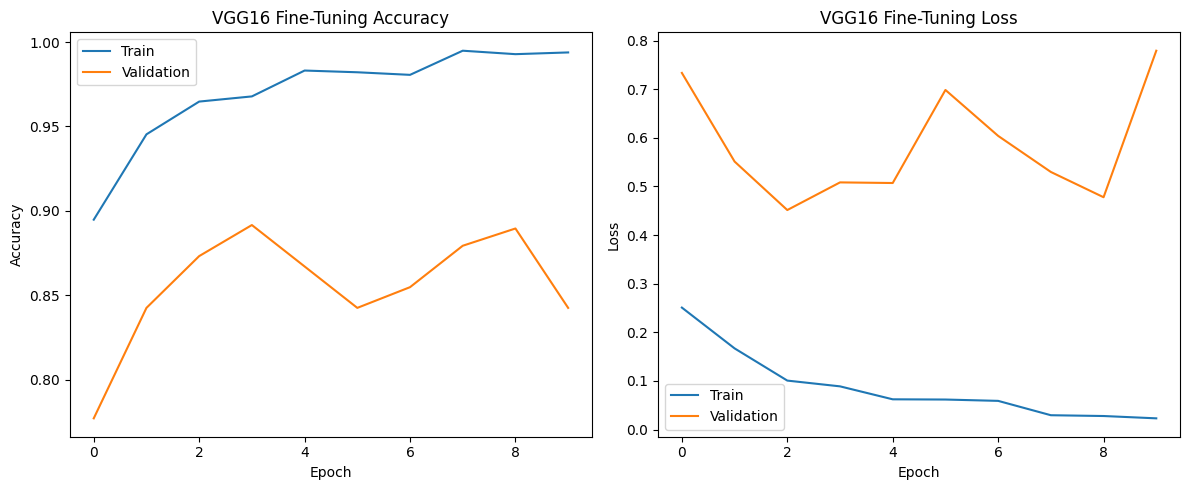

VGG16 (Fine-tuned) Validation Accuracy: 0.8425


In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_finetune.history['accuracy'], label='Train')
plt.plot(history_finetune.history['val_accuracy'], label='Validation')
plt.title('VGG16 Fine-Tuning Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_finetune.history['loss'], label='Train')
plt.plot(history_finetune.history['val_loss'], label='Validation')
plt.title('VGG16 Fine-Tuning Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()

loss_vgg_ft, acc_vgg_ft = vgg_model.evaluate(val_ds, verbose=0)
print(f"VGG16 (Fine-tuned) Validation Accuracy: {acc_vgg_ft:.4f}")


## Part B – Section 2.6.3: Test Set Evaluation and Final Comparison

**Brief requirement:** *Make predictions on test data and compare results with the baseline and deeper models from Part A. Discuss whether transfer learning outperforms training from scratch.*


### Load the held-out test dataset
Loads images from `test_dir` (621 images)  this is data none of the models have ever seen during training.


In [53]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)
print("Test dataset loaded.")


Found 621 files belonging to 4 classes.
Test dataset loaded.


d:\semester6\AI\AI Assesment\venv\lib\site-packages\tensorflow\python\data\ops\structured_function.py:264: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


### Evaluate all four models on the test set
Reports test accuracy and loss for: Baseline CNN, Deeper CNN, VGG16 feature-extraction, VGG16 fine-tuned.


In [54]:
import pandas as pd

print("Evaluating Baseline...")
test_loss_b,  test_acc_b  = baseline_model.evaluate(test_ds, verbose=0)
print("Evaluating Deeper (with Dropout)...")
test_loss_d,  test_acc_d  = model.evaluate(test_ds, verbose=0)
print("Evaluating Deeper (without Dropout – ablation)...")
test_loss_abl, test_acc_abl = model_no_dropout.evaluate(test_ds, verbose=0)
print("Evaluating Deeper (SGD optimizer)...")
test_loss_sgd, test_acc_sgd = model_sgd.evaluate(test_ds, verbose=0)
print("Evaluating VGG16 (feature extraction → fine-tuned)...")
test_loss_v,  test_acc_v  = vgg_model.evaluate(test_ds, verbose=0)

final_df = pd.DataFrame({
    'Model': [
        'Baseline CNN (3 conv + 3 FC)',
        'Deeper CNN (4 conv + 4 FC + BN + Dropout)',
        'Deeper CNN (4 conv + 4 FC + BN, No Dropout)',
        'Deeper CNN (4 conv + 4 FC + BN + Dropout, SGD)',
        'VGG16 (Transfer Learning + Fine-Tuning)'
    ],
    'Test Accuracy': [test_acc_b, test_acc_d, test_acc_abl, test_acc_sgd, test_acc_v],
    'Test Loss':     [test_loss_b, test_loss_d, test_loss_abl, test_loss_sgd, test_loss_v]
})
print("\nFINAL TEST SET COMPARISON:")
print(final_df.to_string(index=False))


Evaluating Baseline...
Evaluating Deeper (with Dropout)...
Evaluating Deeper (without Dropout – ablation)...
Evaluating Deeper (SGD optimizer)...
Evaluating VGG16 (feature extraction → fine-tuned)...

FINAL TEST SET COMPARISON:
                                         Model  Test Accuracy  Test Loss
                  Baseline CNN (3 conv + 3 FC)       0.608696   0.899251
     Deeper CNN (4 conv + 4 FC + BN + Dropout)       0.774557   0.600822
   Deeper CNN (4 conv + 4 FC + BN, No Dropout)       0.727858   0.718383
Deeper CNN (4 conv + 4 FC + BN + Dropout, SGD)       0.560386   1.072957
       VGG16 (Transfer Learning + Fine-Tuning)       0.900161   0.495617


### Classification report on test set – best model (VGG16 fine-tuned)
Per-class precision, recall and F1 on the test set for the best-performing model.


In [55]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true_t, y_pred_t = [], []
for images, labels in test_ds:
    preds = vgg_model.predict(images, verbose=0)
    y_pred_t.extend(np.argmax(preds, axis=1))
    y_true_t.extend(labels.numpy())

print("Test-set Classification Report (VGG16 fine-tuned):")
print(classification_report(y_true_t, y_pred_t, target_names=class_names))
print("Confusion Matrix:")
print(confusion_matrix(y_true_t, y_pred_t))


d:\semester6\AI\AI Assesment\venv\lib\site-packages\tensorflow\python\data\ops\structured_function.py:264: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Test-set Classification Report (VGG16 fine-tuned):
                  precision    recall  f1-score   support

    glioma_tumor       0.89      0.93      0.91       181
meningioma_tumor       0.83      0.89      0.86       183
          normal       0.98      0.72      0.83        88
 pituitary_tumor       0.95      0.97      0.96       169

        accuracy                           0.90       621
       macro avg       0.92      0.88      0.89       621
    weighted avg       0.90      0.90      0.90       621

Confusion Matrix:
[[169  11   1   0]
 [ 14 163   0   6]
 [  6  17  63   2]
 [  0   5   0 164]]


### Visualize test-set predictions from the best model


d:\semester6\AI\AI Assesment\venv\lib\site-packages\tensorflow\python\data\ops\structured_function.py:264: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


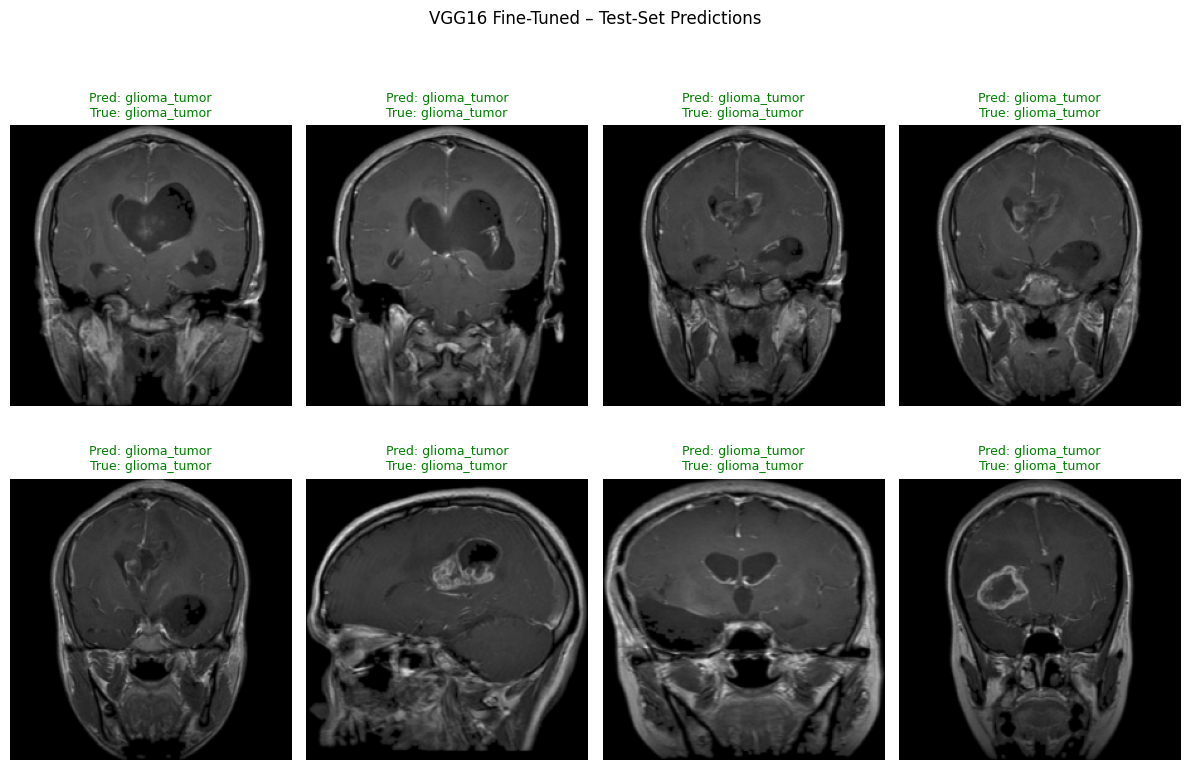

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sample_iter = iter(test_ds.unbatch().take(8))
for i in range(8):
    img, label = next(sample_iter)
    pred = vgg_model.predict(tf.expand_dims(img, 0), verbose=0)
    pred_class = class_names[np.argmax(pred)]
    true_class = class_names[label.numpy()]
    plt.subplot(2, 4, i + 1)
    plt.imshow(img.numpy().astype('uint8'))
    color = 'green' if pred_class == true_class else 'red'
    plt.title(f"Pred: {pred_class}\nTrue: {true_class}", color=color, fontsize=9)
    plt.axis('off')
plt.suptitle("VGG16 Fine-Tuned – Test-Set Predictions", y=1.02)
plt.tight_layout()
plt.show()
